In [19]:
%load_ext autoreload
%autoreload 2
from scripts.utils import *
from scripts.plots import *
from scripts.calibration import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
D,L,labels= init_dataset()
(DTR, LTR), (DVAL, LVAL) = split_db_2to1(D, L)

### 📘 Theory & Key Functions
**Theoretical Recall:** 
- **Calibration**: Uncalibrated models might output scores that do not represent true log-likelihood ratios, causing poor decisions at theoretical thresholds (Actual DCF >> Min DCF). We calibrate scores by training a univariate logistic regression on them.
- **Score Fusion**: Different models (e.g., SVM and GMM) often make different mistakes. Fusion stacks their scores and trains a joint logistic regression model to produce a single, stronger, and inherently calibrated score.
- **K-Fold**: To prevent overfitting during calibration/fusion, we use K-Fold cross-validation to generate unbiased training scores.

**Key Functions (from `calibration.py`):**
- `extract_kfold_calibrated_scores()`: Splits data into $K$ folds, using $K-1$ folds to train a calibration model and applying it to the remaining fold, assembling unbiased calibrated scores.
- `calibrate_scores(scores, w, b)`: Applies the learned linear transformation to new test scores.

 See [calibration.py](../scripts/calibration.py) for the implementation.

In [3]:
llr_gmm_best=np.load('llr/score_gmm_best.npy')
score_lr_best = np.load('llr/score_lr_best.npy')
score_svm_best = np.load('llr/score_svm_best.npy')


llr_migliori = {
    'GMM Full-Cov (8 Comp)': llr_gmm_best,  
    'SVM Polinomiale': score_svm_best,
    'Logistic Regression Quadratica': score_lr_best
}


Let's analyze the current situation with a Bayes Error Plot on the current values.

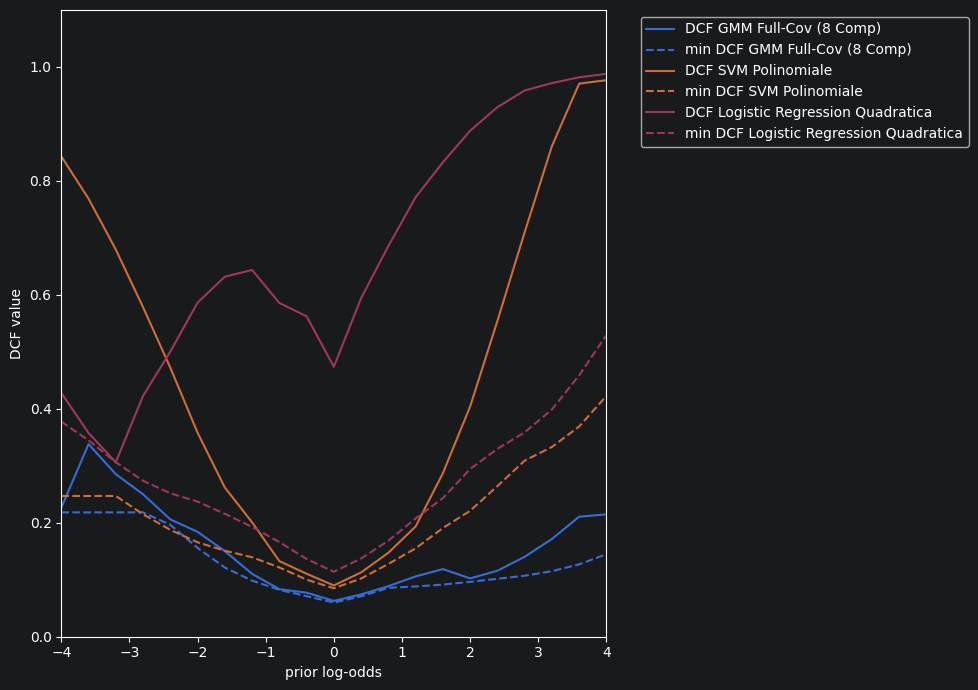

In [4]:
plot_bayes_error(llr_migliori,LVAL)

In [6]:
pi_target=0.5
pi_train_candidates=[0.1,0.2,0.5,0.8,0.9]
calibrated_scores_best = {}

for model_name,raw_scores in llr_migliori.items():
    
    best_act_dcf = float('inf')
    best_pi_train = None
    best_calibrated_scores = None
    print(f"----------------------------{model_name}------------------------------")
    for pi_train in pi_train_candidates:
        cal_scores,pooled_labels=extract_kfold_calibrated_scores(raw_scores,LVAL,pi_train,KFOLD=5)
        pred = get_bayes_decision(cal_scores, pi_target, 1, 1)
        act_dcf = DCF_norm(pred, pooled_labels, pi_target, 1, 1)
        min_dcf = compute_min_dcf(cal_scores, pooled_labels, pi_target, 1, 1)
        print(f"pi_train={pi_train}: minDCF={min_dcf:.3f}, actDCF={act_dcf:.3f}")
    
        if act_dcf < best_act_dcf:
            best_act_dcf = act_dcf
            best_pi_train = pi_train
            best_calibrated_scores = cal_scores

    print(f"Modello migliore {model_name} : pi_train = {best_pi_train} (actDCF: {best_act_dcf:.3f})\n")
    calibrated_scores_best[model_name] = best_calibrated_scores

----------------------------GMM Full-Cov (8 Comp)------------------------------
pi_train=0.1: minDCF=0.060, actDCF=0.064
pi_train=0.2: minDCF=0.060, actDCF=0.063
pi_train=0.5: minDCF=0.060, actDCF=0.063
pi_train=0.8: minDCF=0.060, actDCF=0.062
pi_train=0.9: minDCF=0.060, actDCF=0.061
Modello migliore GMM Full-Cov (8 Comp) : pi_train = 0.9 (actDCF: 0.061)

----------------------------SVM Polinomiale------------------------------
pi_train=0.1: minDCF=0.086, actDCF=0.090
pi_train=0.2: minDCF=0.086, actDCF=0.089
pi_train=0.5: minDCF=0.085, actDCF=0.089
pi_train=0.8: minDCF=0.085, actDCF=0.089
pi_train=0.9: minDCF=0.084, actDCF=0.090
Modello migliore SVM Polinomiale : pi_train = 0.2 (actDCF: 0.089)

----------------------------Logistic Regression Quadratica------------------------------
pi_train=0.1: minDCF=0.112, actDCF=0.114
pi_train=0.2: minDCF=0.113, actDCF=0.113
pi_train=0.5: minDCF=0.113, actDCF=0.113
pi_train=0.8: minDCF=0.114, actDCF=0.115
pi_train=0.9: minDCF=0.114, actDCF=0.115
Mo

Let's now see the Score Fusion.

In [7]:
SFUSION_VAL = np.vstack([
    llr_migliori['GMM Full-Cov (8 Comp)'],
    llr_migliori['SVM Polinomiale'],
    llr_migliori['Logistic Regression Quadratica']
])

print("----------------------------Fusione (GMM + SVM + LR)------------------------------")
best_fusion_dcf = float('inf')
best_fusion_pi = None
best_fusion_scores = None

for pi_train in pi_train_candidates:
    
    pooled_fusion_scores, pooled_fusion_labels = extract_kfold_calibrated_scores(SFUSION_VAL, LVAL, pi_train, KFOLD=5)

    
    min_dcf_val_fusion = compute_min_dcf(pooled_fusion_scores, pooled_fusion_labels, pi_target, 1, 1)
    pred_val_fusion = get_bayes_decision(pooled_fusion_scores, pi_target, 1, 1)
    act_dcf_val_fusion = DCF_norm(pred_val_fusion, pooled_fusion_labels, pi_target, 1, 1)

    print(f"pi_train={pi_train}: minDCF={min_dcf_val_fusion:.3f}, actDCF={act_dcf_val_fusion:.3f}")
    
    
    if act_dcf_val_fusion < best_fusion_dcf:
        best_fusion_dcf = act_dcf_val_fusion
        best_fusion_pi = pi_train
        best_fusion_scores = pooled_fusion_scores

print(f"Modello migliore Fusione : pi_train = {best_fusion_pi} (actDCF: {best_fusion_dcf:.3f})\n")

calibrated_scores_best['Fusion (GMM + SVM + LR)'] = best_fusion_scores

----------------------------Fusione (GMM + SVM + LR)------------------------------
pi_train=0.1: minDCF=0.060, actDCF=0.063
pi_train=0.2: minDCF=0.057, actDCF=0.062
pi_train=0.5: minDCF=0.060, actDCF=0.062
pi_train=0.8: minDCF=0.060, actDCF=0.063
pi_train=0.9: minDCF=0.060, actDCF=0.063
Modello migliore Fusione : pi_train = 0.2 (actDCF: 0.062)



Evaluation phase

In [8]:
#Carichiamo l'intero set di training
dataset_train = np.loadtxt('../trainData.txt', delimiter=',')
D_TRAIN_ALL = dataset_train[:, :6].T
L_TRAIN_ALL = dataset_train[:, 6]

#Carichiamo l'evaluation set
evalData = np.loadtxt('../evalData.txt', delimiter=',')
D_eval=evalData[:,:6].T
L_eval=evalData[:,6]



Let's import the SVM functions from notebook 7.

In [9]:
from scripts.SVM import *

Let's import the Logistic Regression functions.

In [10]:
from scripts.logisticreg import *

Let's import the GMM functions.

In [11]:
from scripts.GMM import *

Now let's extract the scores using these last 3 functions.

In [15]:
eval_raw_gmm=best_GMM(D_TRAIN_ALL,L_TRAIN_ALL,D_eval)
eval_raw_SVM=best_SVM(D_TRAIN_ALL,L_TRAIN_ALL,D_eval)
eval_raw_lr=best_LR(D_TRAIN_ALL,L_TRAIN_ALL,D_eval)

Primal Loss : 17455.689857371704 - Dual Loss : 17455.675491326903


In [16]:
systems = {
    'GMM raw': eval_raw_gmm,
    'SVM raw': eval_raw_SVM,
    'LR raw': eval_raw_lr,
}

print(f"=== Evaluation dataset - raw scores (pi_T = {pi_target}) ===")
for name, scores in systems.items():
    min_dcf = compute_min_dcf(scores, L_eval, pi_target, 1, 1)
    pred = get_bayes_decision(scores, pi_target, 1, 1)
    act_dcf = DCF_norm(pred, L_eval, pi_target, 1, 1)
    print(f"{name} -> minDCF: {min_dcf:.3f}, actDCF: {act_dcf:.3f}")#Prendiamo gli score che i modelli hanno fatto sul Validation e sull'Evaluation


=== Evaluation dataset - raw scores (pi_T = 0.5) ===
GMM raw -> minDCF: 0.071, actDCF: 0.074
SVM raw -> minDCF: 0.092, actDCF: 0.095
LR raw -> minDCF: 0.142, actDCF: 0.490


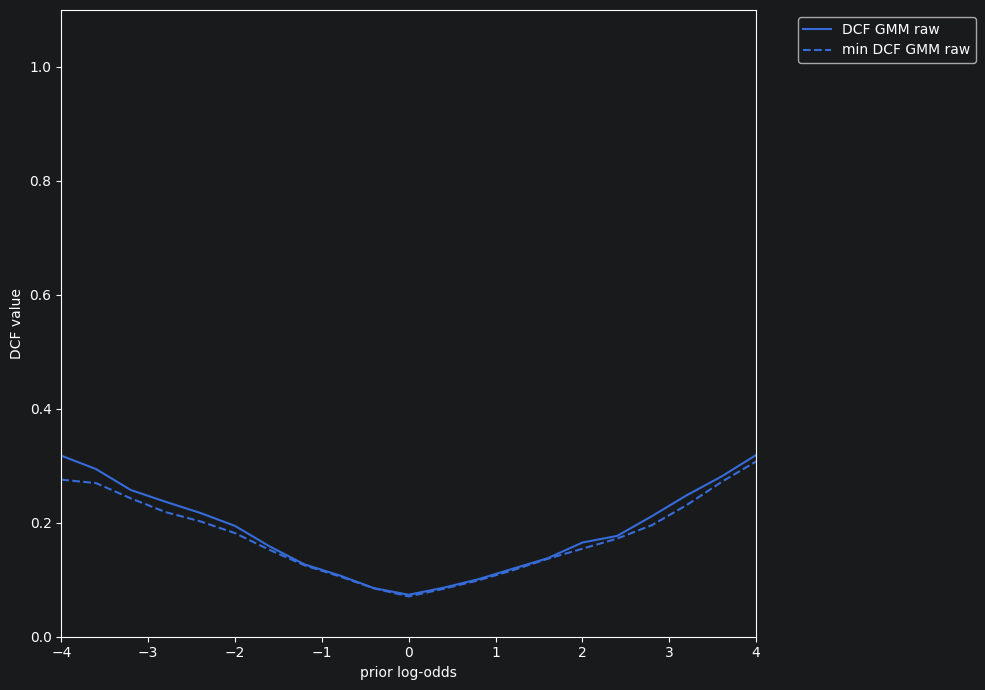

In [17]:
plot_bayes_error({'GMM raw': eval_raw_gmm}, L_eval)

In [20]:
pi_target=0.5
target_log_odds=np.log(pi_target/(1-pi_target))
eval_cal_gmm, _, _ = calibrate_scores(llr_migliori['GMM Full-Cov (8 Comp)'], LVAL, eval_raw_gmm, 0.9, pi_target)

# SVM (con pi_train ottimale = 0.2)
eval_cal_svm, _, _ = calibrate_scores(llr_migliori['SVM Polinomiale'], LVAL, eval_raw_SVM, 0.2, pi_target)

# LR (con pi_train ottimale = 0.2)
eval_cal_lr, _, _ = calibrate_scores(llr_migliori['Logistic Regression Quadratica'], LVAL, eval_raw_lr, 0.2, pi_target)

In [21]:

systems = {
    'GMM calibrato': eval_cal_gmm,
    'SVM calibrato': eval_cal_svm,
    'LR calibrato': eval_cal_lr,
}

print(f"=== Evaluation dataset - Calibrated scores (pi_T = {pi_target}) ===")
for name, scores in systems.items():
    min_dcf = compute_min_dcf(scores, L_eval, pi_target, 1, 1)
    pred = get_bayes_decision(scores, pi_target, 1, 1)
    act_dcf = DCF_norm(pred, L_eval, pi_target, 1, 1)
    print(f"{name} -> minDCF: {min_dcf:.3f}, actDCF: {act_dcf:.3f}")#Prendiamo gli score che i modelli hanno fatto sul Validation e sull'Evaluation



=== Evaluation dataset - Calibrated scores (pi_T = 0.5) ===
GMM calibrato -> minDCF: 0.071, actDCF: 0.114
SVM calibrato -> minDCF: 0.092, actDCF: 0.120
LR calibrato -> minDCF: 0.142, actDCF: 0.173


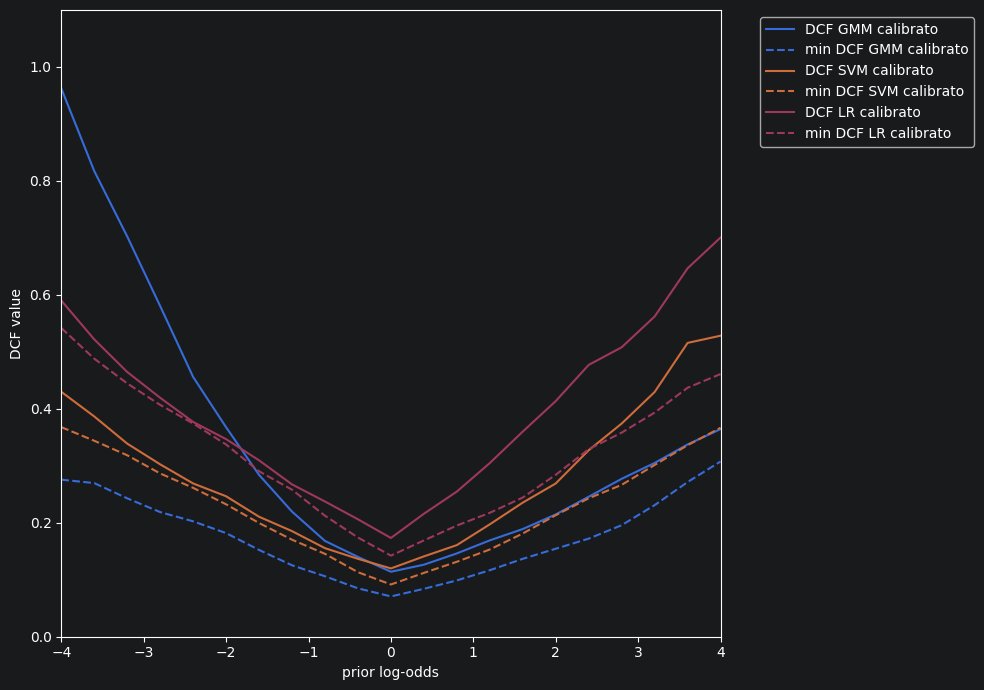

In [22]:
plot_bayes_error(systems,L_eval)

In [23]:
SFUSION_VAL = np.vstack([
    llr_migliori['GMM Full-Cov (8 Comp)'], 
    llr_migliori['SVM Polinomiale'], 
    llr_migliori['Logistic Regression Quadratica']
])

SFUSION_EVAL = np.vstack([eval_raw_gmm, eval_raw_SVM, eval_raw_lr])

v_opt_fus,_=weighted_trainLogReg(SFUSION_VAL,LVAL,0.0,0.2)
#Estraiamo i pesi
alpha_fus = v_opt_fus[0:-1].reshape(-1, 1)
gamma_fus = v_opt_fus[-1] - target_log_odds
#Calcoliamo il punto di fusione 
eval_cal_fusion = (np.dot(alpha_fus.T, SFUSION_EVAL) + gamma_fus).ravel()

In [24]:
min_dcf = compute_min_dcf(eval_cal_fusion, L_eval, pi_target, 1, 1)
pred = get_bayes_decision(eval_cal_fusion, pi_target, 1, 1)
act_dcf = DCF_norm(pred, L_eval, pi_target, 1, 1)
print(f"Score fusion GMM + SVM + LR -> minDCF: {min_dcf:.3f}, actDCF: {act_dcf:.3f}")#Prendiamo gli score che i modelli hanno fatto sul Validation e sull'Evaluation
error_rate = np.mean(pred != L_eval)
print(f"Error rate: {error_rate:.3f}")

Score fusion GMM + SVM + LR -> minDCF: 0.072, actDCF: 0.090
Error rate: 0.045


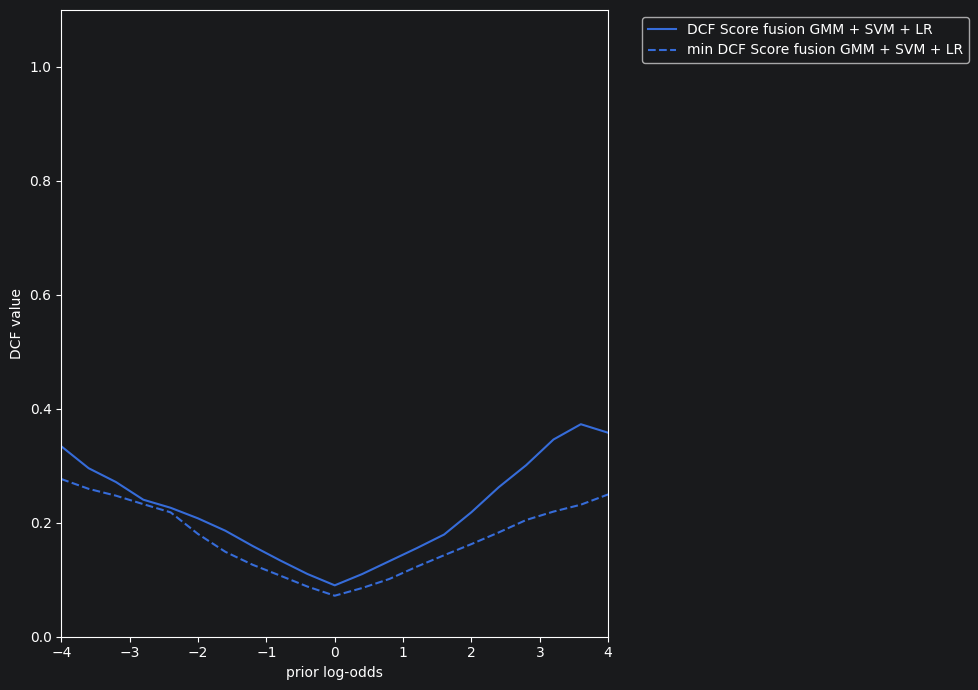

In [25]:
plot_bayes_error({"Score fusion GMM + SVM + LR":eval_cal_fusion},L_eval)